# Aula 4 - Como as Redes Neurais Aprendem? - *Multilayer Perceptron*

### A Classe `Valor`

In [1]:
import math

class Valor:

    # __init__ é a função que cria uma nova instância (um novo objeto) da classe
    def __init__(self, dado, _dependencias=(), _op='', rotulo=''):
        self.dado = dado                # o valor que o parâmetro assume

        self.grad = 0.0                 # ∂L/∂self, a derivada do parâmetro,
                                        # porém, inicializada como 0.0

        self._prev = set(_dependencias) # conjunto das dep. imediatas deste parâmetro

        self._retro = lambda: None      # expressão que calcula as derivadas
                                        # das dependências deste objeto

        # atributos para legibilidade
        self._op = _op                  # operação (e.g.: +, *) que produz este parâmetro
        self.rotulo = rotulo            # rótulo para identificação do objeto
    
    # __repr__ retorna uma representação textual do objeto
    def __repr__(self):
        return f"Valor(data={self.dado})"
    
    # __add__ define como somar dois objetos da classe `Valor`
    def __add__(self, outro):
        # se `outro` não é um objeto `Valor`, assumimos que é um número
        outro = outro if isinstance(outro, Valor) else Valor(outro)

        saida = Valor(self.dado + outro.dado, (self, outro), '+')

        # resumo da ópera: uma soma simplesmente repassa o gradiente do vértice de saída a suas dependências 
        # prova:
        # S(p1,p2) = p1+p2 => ∂S/∂pi = 1
        # ∂L/∂pi = ∂L/∂S * ∂S/∂pi = ∂L/∂S * 1 = ∂L/∂S
        def _retro():
            self.grad += saida.grad * 1.0
            outro.grad += saida.grad * 1.0
        saida._retro = _retro

        return saida
    
    # trocamos 2.__add__(a) por a.__radd__(2)
    def __radd__(self, outro):
        return self + outro 

    # __mul__ define como multiplicar dois objetos da classe `Valor`
    def __mul__(self, outro):
        # se `outro` não é um objeto `Valor`, assumimos que é um número
        outro = outro if isinstance(outro, Valor) else Valor(outro)

        saida = Valor(self.dado * outro.dado, (self, outro), '*')

        def _retro():
            self.grad  += saida.grad * outro.dado
            outro.grad += saida.grad * self.dado
        saida._retro = _retro

        return saida

    # trocamos 2.__mul__(a) por a.__rmul__(2)
    def __rmul__(self, outro):
        return self * outro 
    
    def __neg__(self):
        # self.__mul__(-1)
        return self * -1
    
    def __sub__(self, outro):
        # self.__add__(outro.__neg__())
        return self + (-outro)
    
    def __pow__(self, potencia):
        assert isinstance(potencia, (int, float)) # apenas potências constantes do tipo int/float

        saida = Valor(self.dado**potencia, (self,), f'**{potencia}')

        def _retro():
            self.grad += saida.grad * (potencia * self.dado ** (potencia-1))
        saida._retro = _retro

        return saida
    
    def tanh(self):
        t = math.tanh(self.dado)
        saida = Valor(t, (self,), 'tanh')

        def _retro():
            self.grad += saida.grad * (1 - t**2)
        saida._retro = _retro

        return saida
    
    
    def retropropag(self):
        grafo = []
        visitado = set()

        def ord_topologica(v):
            if v not in visitado:
                visitado.add(v)
                for prev in v._prev:
                    ord_topologica(prev)
                grafo.append(v)
        
        ord_topologica(self)

        self.grad = 1.0
        for v in reversed(grafo):
            v._retro()

### Auxilio para a Visualização de Grafos

In [ ]:
from graphviz import Digraph

def traco(raiz):
# `traco()` retorna a "árvore genealógica" do vértice `raiz`
    vertices, arcos = set(), set()

    def construir(v):
        if v not in vertices:
            vertices.add(v)
            for prev in v._prev:
                arcos.add((prev, v))
                construir(prev)
    
    construir(raiz)
    return vertices, arcos 


def desenhe_grafo(raiz):
    imagem = Digraph(
        format     = 'svg',            # formato de imagem vetorizada
        graph_attr = {'rankdir': 'LR'} # grafo flui da esquerda a direita
    )

    vertices, arcos = traco(raiz)
    for v in vertices:
        chave = str(id(v))

        # adiciona vértice `v` à imagem
        imagem.node(
            name  = chave,                                                         # id do vértice
            label = "{ %s | dado %.4f | grad %.4f }" % (v.rotulo, v.dado, v.grad), # conteúdo do vértice
            shape = 'record'                                                       # formato de vértice retangular
        )

        # se este vértice é resultado de uma operação,
        # desenha um pseudo-vértice para indicar a operação
        if v._op:
            imagem.node(
                name  = chave + v._op,  # id do pseudo-vértice
                label = v._op           # conteúdo do pseudo-vértice
            )
            # e conecta os dois por meio de um arco
            imagem.edge(chave + v._op, chave)
    
    for a in arcos:
        prev = a[0]
        v    = a[1]

        # conecta o vértice `prev` à operação do vértice `v`
        imagem.edge(str(id(prev)), str(id(v)) + v._op)
    
    return imagem 

### Neurônio Artificial

In [3]:
# entradas (estímulos)
x1 = Valor(2.0, rotulo='x1')
x2 = Valor(0.0, rotulo='x2')

# pesos dos dendritos
p1 = Valor(-3.0, rotulo='p1')
p2 = Valor(1.0, rotulo='p2')

# viés do neurônio (a propensão inata do neurônio de disparar)
vies = Valor(6.8813736, rotulo='vies')

# Objetos `Valor` intermediários
sinal1 = x1*p1; sinal1.rotulo = 'sinal1'
sinal2 = x2*p2; sinal2.rotulo = 'sinal2'
sinal_total = sinal1 + sinal2; sinal_total.rotulo = 'sinal_total'

# Pré-ativação
z = sinal_total + vies; z.rotulo='z'

# Saída
saida = z.tanh(); saida.rotulo='saida'

In [4]:
saida.retropropag()

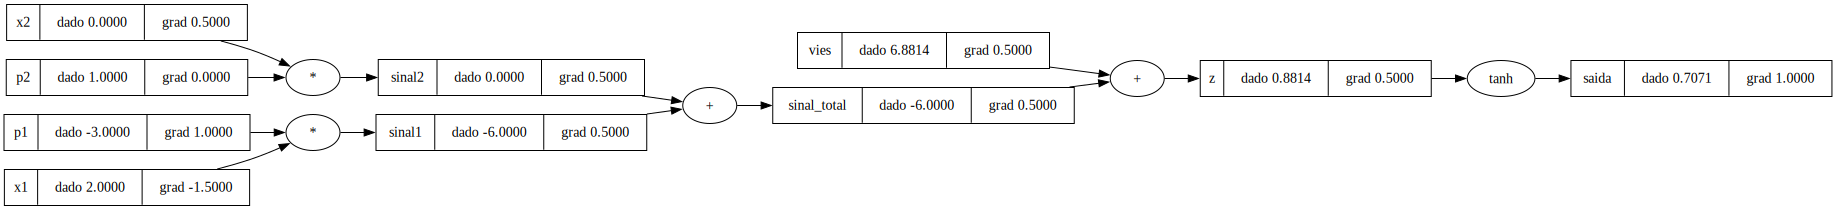

In [5]:
desenhe_grafo(saida)

### Multilayer Perceptron (Perceptron de Múltiplas Camadas)

In [6]:
import random

In [7]:
class Neuronio:
    def __init__(self, nin):    # `nin` designa "número de inputs"
        self.pesos = [Valor(random.uniform(-1,1)) for _ in range(nin)]
        self.vies = Valor(random.uniform(-1,1))
    
    # O método __call__ permite que objetos sejam chamados como fazemos com funções
    def __call__(self, estimulo):
        # z = Σ(pi * xi) + b
        ativ_bruta = sum(pi*xi for pi, xi in zip(self.pesos, estimulo)) + self.vies
        ativ_achatada = ativ_bruta.tanh()
        return ativ_achatada 
    
    def parametros(self):
        return self.pesos + [self.vies]

In [8]:
n = Neuronio(3)       # `n` é um objeto `Neuronio` com 3 "dendritos" (i.e.: 3 pesos)

x = [2.0, 3.0, -1.0]  # um estímulo `x`
                      # `x[0]` é o estímulo ao primeiro dendrito do neurônio `n`
                      # `x[1]` o estímulo ao seu segundo, e `x[2]` ao seu terceiro

ativacao = n(x)       # i.e.: n.__call__(x)
print(f"Quando estimulado por {x}, o neurônio `n` tem uma ativação de {ativacao.dado}")

Quando estimulado por [2.0, 3.0, -1.0], o neurônio `n` tem uma ativação de -0.8467538656762994


In [9]:
class Camada:
    def __init__(self, nin, nout):
        self.neuronios = [Neuronio(nin) for _ in range(nout)]
    
    def __call__(self, x):
        saidas = [n(x) for n in self.neuronios]
        return saidas

    def parametros(self):
        #params = []
        #for neuronio in self.neuronios:
        #    ps = neuronio.parametros()
        #    params.extend(ps)
        #return params
        return [pr for neuronio in self.neuronios for pr in neuronio.parametros()]

In [10]:
c = Camada(3,2)       # `c` é um objeto `Camada` possuindo
                      # 2 neurônios de 3 dendritos cada

x = [2.0, 3.0, -1.0]  # um estímulo `x`

ativacoes = c(x)      # i.e.: c.__call__(x)

print(f"Para um estímulo de {x}, as ativações (independentes) de cada neurônio da camada `c` são:")
print(ativacoes)

Para um estímulo de [2.0, 3.0, -1.0], as ativações (independentes) de cada neurônio da camada `c` são:
[Valor(data=0.9769530600015787), Valor(data=0.990147159414726)]


In [11]:
class MLP:
    def __init__(self, nin, nouts):
        t = [nin] + nouts   # `t` de tamanho
        self.camadas = [Camada(t[i], t[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for camada in self.camadas:
            x = camada(x)
        return x[0] if len(x) == 1 else x
    
    def parametros(self):
        return [pr for camada in self.camadas for pr in camada.parametros()]

In [12]:
mlp = MLP(3, [4,4,1])   # `mlp` é um objeto `MLP` de 3 entradas
                        # seguido de uma camada de 4 neurônios,
                        # outra de 4, e uma final com apenas 1.

x = [2.0, 3.0, -1.0]    # um dado `x`

saida = mlp(x)          # i.e.: mlp.__call__(x)

print(f"Quando alimentado do dado {x}, a rede neural `mlp` produz a saída {saida.dado}")

Quando alimentado do dado [2.0, 3.0, -1.0], a rede neural `mlp` produz a saída 0.0570425329077901


#### Alimentando Dados ao nosso MLP

In [13]:
# quatro possíveis inputs para o MLP
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

# o alvo desejado para cada input (alvos binários!)
ys = [ 1.0,
      -1.0,
      -1.0,
       1.0]

for k in range(100):
    # propagação direta (i.e. para frente) 
    y_prev = [mlp(x) for x in xs]
    perda = sum([(y - y_alvo)**2 for y, y_alvo in zip(y_prev, ys)])

    # retropropagação
    for param in mlp.parametros():
        param.grad = 0.0
    perda.retropropag()

    # atualização
    for param in mlp.parametros():
        param.dado += -0.2 * param.grad
    
    print(f"iter. {k}: L = {perda.dado}")

iter. 0: L = 3.1456936179816286
iter. 1: L = 0.9114120651960804
iter. 2: L = 0.12920775463930398
iter. 3: L = 0.040131401979171664
iter. 4: L = 0.031010779503370736
iter. 5: L = 0.025257080500631787
iter. 6: L = 0.021285881367204114
iter. 7: L = 0.018377966795536493
iter. 8: L = 0.016156681049337592
iter. 9: L = 0.014404919991278634
iter. 10: L = 0.01298850196254417
iter. 11: L = 0.011819947559733604
iter. 12: L = 0.0108397589984588
iter. 13: L = 0.010006051007376199
iter. 14: L = 0.009288480314471999
iter. 15: L = 0.008664526286134122
iter. 16: L = 0.00811712360450341
iter. 17: L = 0.007633105855622333
iter. 18: L = 0.007202153257660104
iter. 19: L = 0.006816063689859597
iter. 20: L = 0.0064682367494063985
iter. 21: L = 0.006153301571771595
iter. 22: L = 0.005866843754493504
iter. 23: L = 0.005605201909765657
iter. 24: L = 0.005365313982552758
iter. 25: L = 0.0051445996935219045
iter. 26: L = 0.0049408695778561645
iter. 27: L = 0.0047522538589043805
iter. 28: L = 0.004577146290663371


In [14]:
# Previsões após o treinamento do MLP
print(y_prev)

[Valor(data=0.983284977875908), Valor(data=-0.9891798051507634), Valor(data=-0.9844811127150812), Valor(data=0.9757149849864807)]


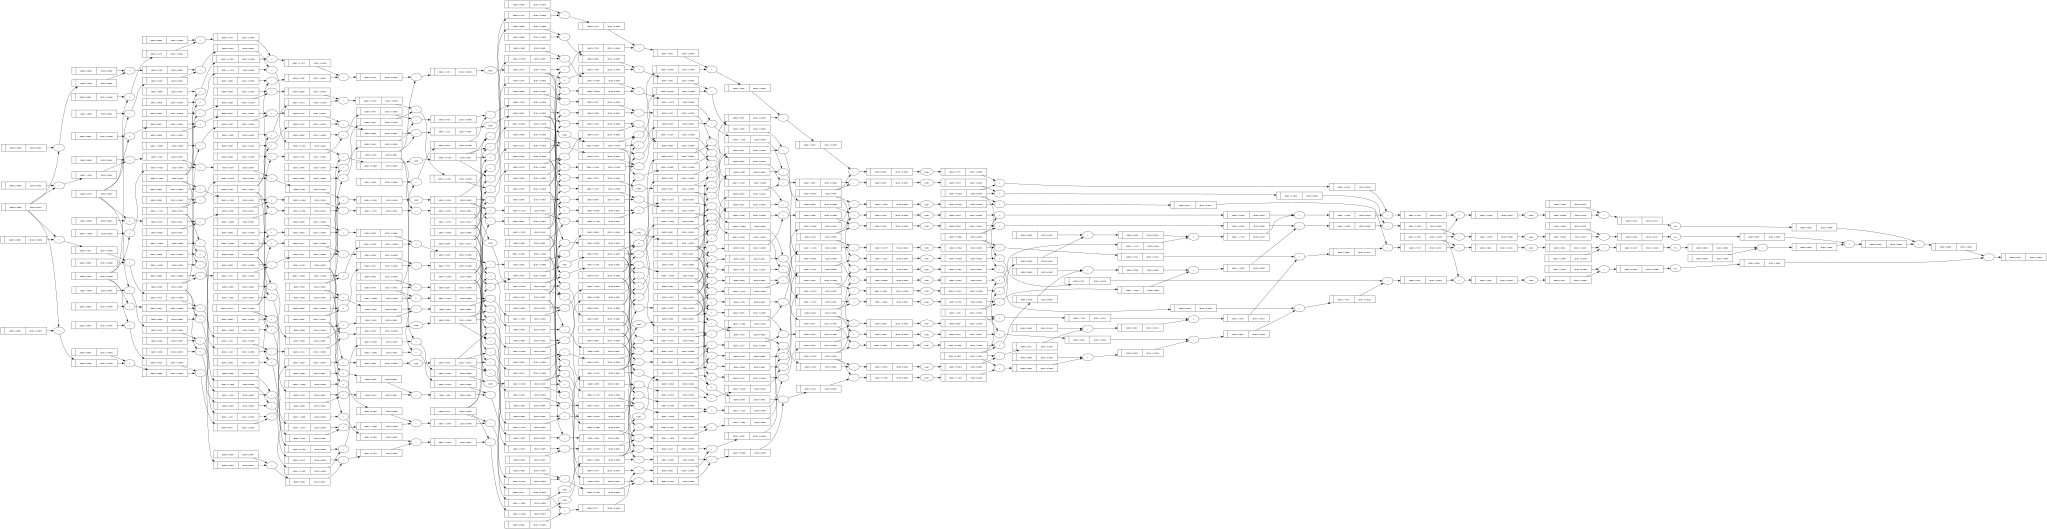

In [15]:
desenhe_grafo(perda)